# Customer Churn Prediction
### Internship Assessment — AI & Machine Learning
---
**Dataset:** IBM Telco Customer Churn (Kaggle)  
**Objective:** Predict which customers are likely to churn using Machine Learning models and rule-based logic, then compare model performances to find the best approach.

---
> *"I got this dataset and honestly had no idea how serious churn actually was for businesses until I started digging into the numbers. Turns out keeping a customer is way cheaper than finding a new one — and that made this problem feel worth solving properly."*

So this is my attempt at building a full pipeline — loading the data, cleaning it up,
training a few models, and figuring out which one actually works best. I'll also note
where I got confused or had to try a different approach, because that happened more than once.


## 1. Loading the Dataset

The dataset used is the **IBM Telco Customer Churn** dataset from Kaggle.  
I've gone through this entire dataset. It has **7,043 rows** and **21 columns**, covering demographics, services subscribed, billing info, and churn status.

**Columns:**

| Task Spec | Telco Column | Reason |
|-----------|-------------|--------|
| Age | `SeniorCitizen` | Age-group indicator |
| Income | `MonthlyCharges` | Monthly billing amount |
| Purchases | `tenure` + services | Duration + service count |
| Membership | `Contract` | Contract type |
| Churn | `Churn` | Direct match |


> **Note:** I renamed and mapped the columns to align with the task spec while keeping the original data intact in a separate file.


In [1]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

dataset_raw=pd.read_csv('C:\Customer_Churn_Prediction\Data\Raw_Dataset\WA_Fn-UseC_-Telco-Customer-Churn.csv')
print("Dataset_shape:",dataset_raw.shape)
print("Columns:",len(dataset_raw.columns),list(dataset_raw.columns))
dataset_raw.head()


<>:6: SyntaxWarning: invalid escape sequence '\C'
<>:6: SyntaxWarning: invalid escape sequence '\C'
C:\Users\janar\AppData\Local\Temp\ipykernel_17064\1434496632.py:6: SyntaxWarning: invalid escape sequence '\C'
  dataset_raw=pd.read_csv('C:\Customer_Churn_Prediction\Data\Raw_Dataset\WA_Fn-UseC_-Telco-Customer-Churn.csv')


Dataset_shape: (7043, 21)
Columns: 21 ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [2]:
#Mapping columns to match the task specification. This makes the dataset align with what the assessment asked for
column_mapping={
    'SeniorCitizen': 'Age',
    'MonthlyCharges': 'Income',
    'Contract': 'Membership',
    'Churn': 'Churn'
}
data=dataset_raw.copy()

service_cols = ['PhoneService', 'MultipleLines', 'InternetService',
                'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
                'TechSupport', 'StreamingTV', 'StreamingMovies']

# Created a Purchase column it contains no. of active services per customer this represents how many products/services a customer has brought
data['Purchases'] = data[service_cols].apply(
    lambda row: sum(1 for val in row if val not in ['No', 'No internet service', 'No phone service']),
    axis=1
)

data.rename(columns=column_mapping, inplace=True)

# Keeping only 5 required columns plus few supporting ones for better modelling
keep_cols = ['Age', 'Income', 'Purchases', 'Membership', 'Churn',
             'tenure', 'TotalCharges', 'gender', 'Partner', 'Dependents',
             'PaperlessBilling', 'PaymentMethod']
data= data[keep_cols]

print("Mapped dataset:")
print(data.head())
print("\nShape after mapping:",data.shape)


Mapped dataset:
   Age  Income  Purchases      Membership Churn  tenure TotalCharges  gender  \
0    0   29.85          2  Month-to-month    No       1        29.85  Female   
1    0   56.95          4        One year    No      34       1889.5    Male   
2    0   53.85          4  Month-to-month   Yes       2       108.15    Male   
3    0   42.30          4        One year    No      45      1840.75    Male   
4    0   70.70          2  Month-to-month   Yes       2       151.65  Female   

  Partner Dependents PaperlessBilling              PaymentMethod  
0     Yes         No              Yes           Electronic check  
1      No         No               No               Mailed check  
2      No         No              Yes               Mailed check  
3      No         No               No  Bank transfer (automatic)  
4      No         No              Yes           Electronic check  

Shape after mapping: (7043, 12)


## 2. Exploratory Data Analysis (EDA)

In [3]:
print("=" * 50)
print("DATASET OVERVIEW")
print("=" * 50)
print(data.info())
print("\nMissing values per column:")
print(data.isnull().sum())
data.describe()

DATASET OVERVIEW
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Age               7043 non-null   int64  
 1   Income            7043 non-null   float64
 2   Purchases         7043 non-null   int64  
 3   Membership        7043 non-null   object 
 4   Churn             7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   TotalCharges      7043 non-null   object 
 7   gender            7043 non-null   object 
 8   Partner           7043 non-null   object 
 9   Dependents        7043 non-null   object 
 10  PaperlessBilling  7043 non-null   object 
 11  PaymentMethod     7043 non-null   object 
dtypes: float64(1), int64(3), object(8)
memory usage: 660.4+ KB
None

Missing values per column:
Age                 0
Income              0
Purchases           0
Membership          0
Churn               0
tenure     

,Age,Income,Purchases,tenure
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,64.761692,4.146244,32.371149
std,0.368612,30.090047,2.312720,24.559481
min,0.000000,18.250000,1.000000,0.000000
25%,0.000000,35.500000,2.000000,9.000000
50%,0.000000,70.350000,4.000000,29.000000
75%,0.000000,89.850000,6.000000,55.000000
max,1.000000,118.750000,9.000000,72.000000


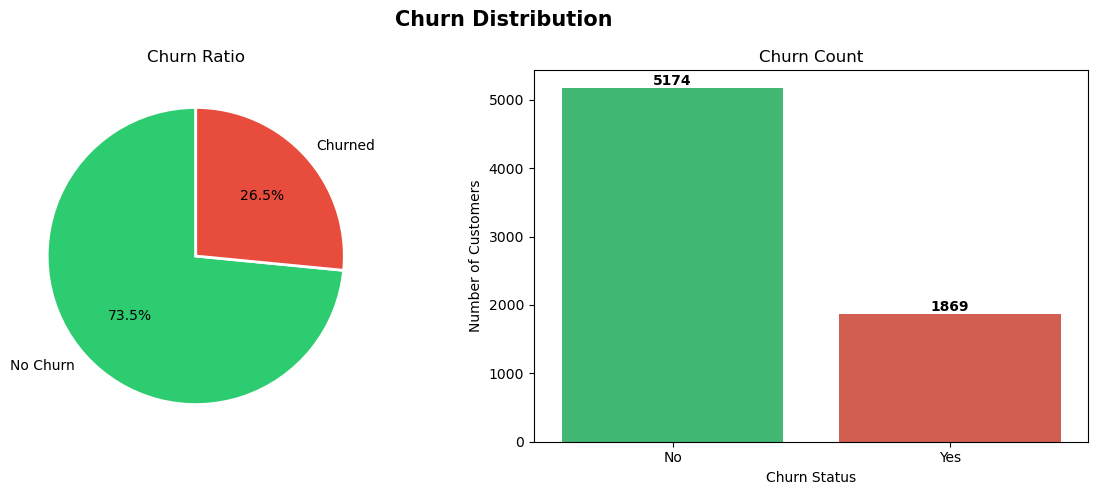


Churn rate: 26.5%
Class imbalance detected


In [4]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Churn Distribution', fontsize=15, fontweight='bold')

# PIE CHART
churn_count = data['Churn'].value_counts()
colors = ['#2ecc71', '#e74c3c']
axes[0].pie(churn_count, labels=['No Churn', 'Churned'],
            autopct='%1.1f%%', colors=colors, startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[0].set_title('Churn Ratio')

# COUNT PLOT
sns.countplot(data=data, x='Churn', palette={'No': '#2ecc71', 'Yes': '#e74c3c'}, ax=axes[1])
axes[1].set_title('Churn Count')
axes[1].set_xlabel('Churn Status')
axes[1].set_ylabel('Number of Customers')
for bar in axes[1].patches:
    axes[1].annotate(f'{int(bar.get_height())}',
                     (bar.get_x() + bar.get_width() / 2, bar.get_height()),
                     ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig('../results/churn_distribution.png', bbox_inches='tight')
plt.show()

print(f"\nChurn rate: {(data['Churn']=='Yes').mean()*100:.1f}%")
print("Class imbalance detected")

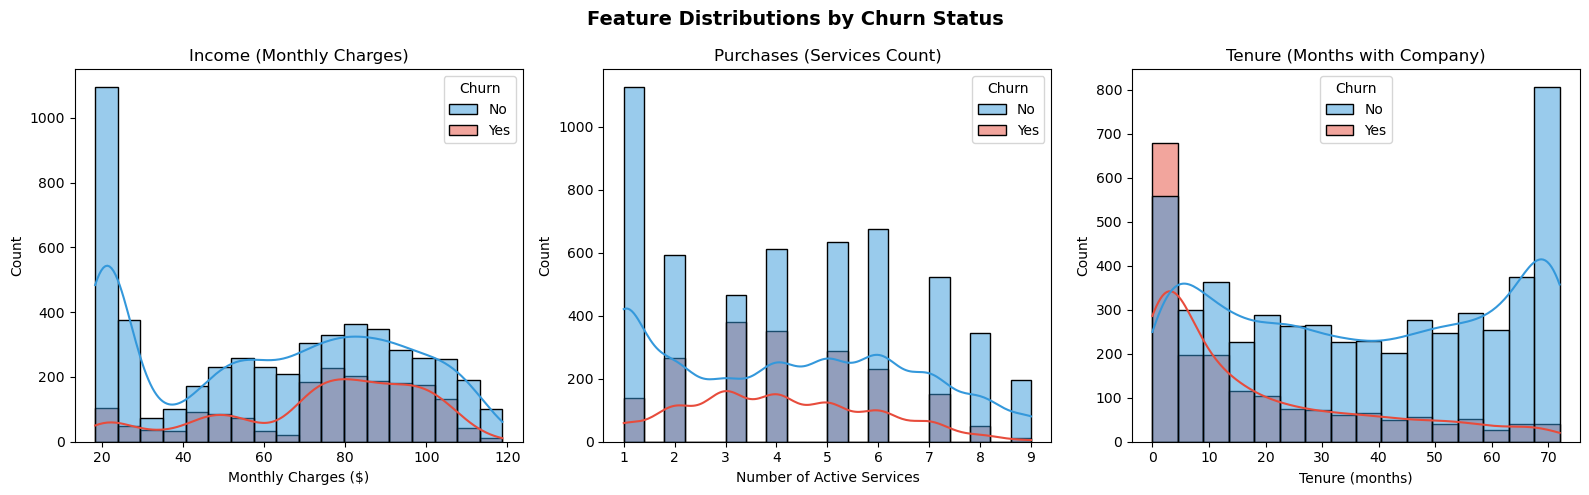

In [5]:
#Distribution by churn
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Feature Distributions by Churn Status', fontsize=14, fontweight='bold')

# Income distribution
sns.histplot(data=data, x='Income', hue='Churn', kde=True,
             palette={'No': '#3498db', 'Yes': '#e74c3c'}, ax=axes[0])
axes[0].set_title('Income (Monthly Charges)')
axes[0].set_xlabel('Monthly Charges ($)')

# Purchases distribution
sns.histplot(data=data, x='Purchases', hue='Churn', kde=True,
             palette={'No': '#3498db', 'Yes': '#e74c3c'}, ax=axes[1])
axes[1].set_title('Purchases (Services Count)')
axes[1].set_xlabel('Number of Active Services')

# Tenure distribution
sns.histplot(data=data, x='tenure', hue='Churn', kde=True,
             palette={'No': '#3498db', 'Yes': '#e74c3c'}, ax=axes[2])
axes[2].set_title('Tenure (Months with Company)')
axes[2].set_xlabel('Tenure (months)')

plt.tight_layout()
plt.savefig('../results/feature_distributions.png', bbox_inches='tight')
plt.show()


## 4. Data Cleaning

In this dataset, `TotalCharges` has error values. It's stored as a string instead of a number, and some rows have blank spaces instead of actual values. I caught this by checking `df.info()`.

In [6]:
# Because of white space entries 'TotalCharges' is stored as object

print("Before fix:")
print(f"  TotalCharges dtype: {data['TotalCharges'].dtype}")
print(f"  Sample values: {data['TotalCharges'].head().tolist()}")

data['TotalCharges'] = pd.to_numeric(data['TotalCharges'], errors='coerce')

print("\nAfter conversion:")
print(f"  TotalCharges dtype: {data['TotalCharges'].dtype}")
print(f"  NaN count: {data['TotalCharges'].isnull().sum()}")

Before fix:
  TotalCharges dtype: object
  Sample values: ['29.85', '1889.5', '108.15', '1840.75', '151.65']

After conversion:
  TotalCharges dtype: float64
  NaN count: 11


In [7]:
missing = data.isnull().sum()
missing = missing[missing > 0]
print("Columns with missing values:")
print(missing)

#filling missing values with 0
data['TotalCharges'] = data['TotalCharges'].fillna(0)

print(f"\nMissing values after fix: {data.isnull().sum().sum()}")
print("Dataset is clean")

Columns with missing values:
TotalCharges    11
dtype: int64

Missing values after fix: 0
Dataset is clean


In [8]:
# Checking for duplicate values
dups = data.duplicated().sum()
print(f"Duplicate rows: {dups}")
if dups > 0:
    data.drop_duplicates(inplace=True)
    print(f"Removed {dups} duplicate(s)")
else:
    print("No duplicates found")

# Quick sanity check on value ranges
print(f"\nIncome range: ${data['Income'].min():.2f} — ${data['Income'].max():.2f}")
print(f"Purchases range: {data['Purchases'].min()} — {data['Purchases'].max()} services")
print(f"Tenure range: {data['tenure'].min()} — {data['tenure'].max()} months")


Duplicate rows: 23
Removed 23 duplicate(s)

Income range: $18.25 — $118.75
Purchases range: 1 — 9 services
Tenure range: 0 — 72 months


## 5. Feature Engineering & Encoding

Converting Categorical variables are converted to numbers for training the models.  
I'm using **Label Encoding** for binary columns and **pd.get_dummies** for multi-class ones.

I also created one extra feature **charges_per_service** which divides monthly income by the number of purchases. This gives a "value per service" metric that could signal dissatisfied customers paying high amounts for few services.

In [9]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.utils.class_weight import compute_class_weight

# For Binary columns (Label Encoding) 
le = LabelEncoder()

binary_cols = ['gender', 'Partner', 'Dependents', 'PaperlessBilling', 'Churn']
for col in binary_cols:
    data[col] = le.fit_transform(data[col])
    print(f"Encoded '{col}': {dict(zip(le.classes_, le.transform(le.classes_)))}")

print()

# For Multi-class categorical (One-Hot Encoding) 
multi_cols = ['Membership', 'PaymentMethod']
data = pd.get_dummies(data, columns=multi_cols, drop_first=True)
print(f"After one-hot encoding, shape: {data.shape}")


Encoded 'gender': {'Female': 0, 'Male': 1}
Encoded 'Partner': {'No': 0, 'Yes': 1}
Encoded 'Dependents': {'No': 0, 'Yes': 1}
Encoded 'PaperlessBilling': {'No': 0, 'Yes': 1}
Encoded 'Churn': {'No': 0, 'Yes': 1}

After one-hot encoding, shape: (7020, 15)


In [10]:
# Feature Engineering
# My idea here is if a customer paying a lot but using fewer services might be more likely to churn
# they might feel they're not getting value for money)
data['charges_per_service'] = data['Income'] / (data['Purchases'] + 1)

# Age group — convert Senior Citizen binary to more descriptive label
data['is_senior'] = data['Age']

print("New features added:")
print(f"  charges_per_service: avg = {data['charges_per_service'].mean():.2f}")
print(f"  is_senior: {data['is_senior'].value_counts().to_dict()}")
print(f"\nFinal feature set ({data.shape[1]} columns):")
print(data.columns.tolist())

New features added:
  charges_per_service: avg = 12.63
  is_senior: {0: 5879, 1: 1141}

Final feature set (17 columns):
['Age', 'Income', 'Purchases', 'Churn', 'tenure', 'TotalCharges', 'gender', 'Partner', 'Dependents', 'PaperlessBilling', 'Membership_One year', 'Membership_Two year', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check', 'charges_per_service', 'is_senior']


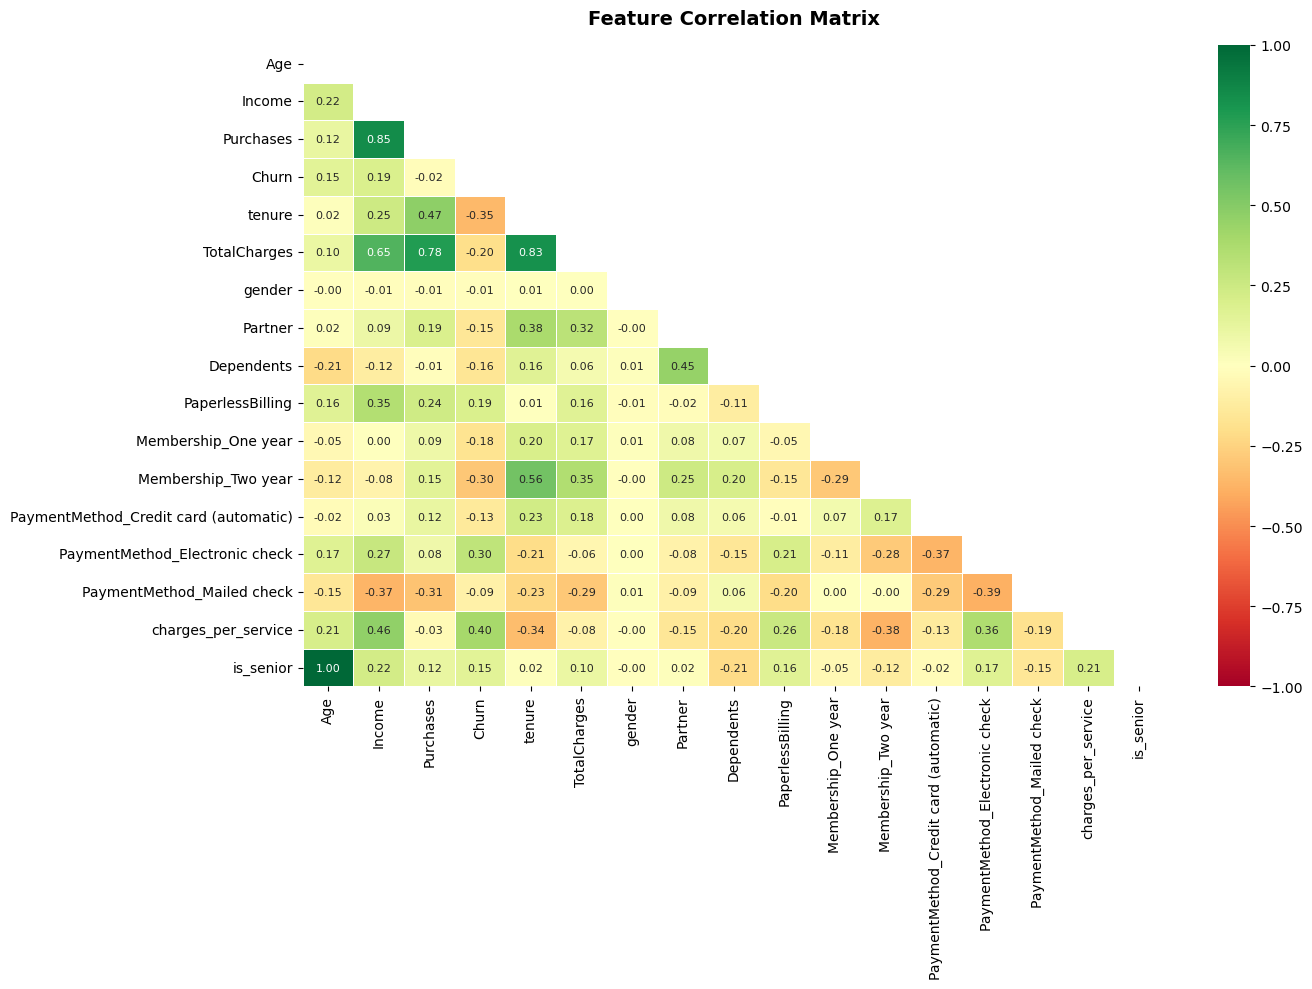


Top features correlated with Churn:
charges_per_service               0.396766
tenure                            0.351668
Membership_Two year               0.302138
PaymentMethod_Electronic check    0.301502
TotalCharges                      0.197301
Income                            0.194473
PaperlessBilling                  0.190976
Membership_One year               0.177388
Dependents                        0.163524
Age                               0.151587
Name: Churn, dtype: float64


In [11]:
#Correlation heatmap
plt.figure(figsize=(14, 10))
corr_matrix = data.corr()

mask = np.zeros_like(corr_matrix, dtype=bool)
mask[np.triu_indices_from(mask)] = True

sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdYlGn', center=0, linewidths=0.5,
            annot_kws={'size': 8}, vmin=-1, vmax=1)
plt.title('Feature Correlation Matrix', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('../results/correlation_heatmap.png', bbox_inches='tight')
plt.show()

# Top correlations with Churn
print("\nTop features correlated with Churn:")
churn_corr = corr_matrix['Churn'].drop('Churn').abs().sort_values(ascending=False)
print(churn_corr.head(10))

## 6. Train-Test Split & Handling Class Imbalance

The dataset has ~26% churners and ~74% non-churners, a classic imbalance problem.  
So, If I train a model as it will just predict "No Churn" most of the time and still get 74% accuracy.  
That's a useless model. So I apply **SMOTE** on the training  
set only not on the test set, because the test set must reflect real-world distribution.


In [12]:
# Separate features and target
target_col = 'Churn'
X = data.drop(columns=[target_col])
y = data[target_col]

print(f"Features: {X.shape[1]} columns, {X.shape[0]} rows")
print(f"Target distribution:\n{y.value_counts()}\n")


Features: 16 columns, 7020 rows
Target distribution:
Churn
0    5163
1    1857
Name: count, dtype: int64



In [13]:
# Train/Test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape[0]}")
print(f"Test set    : {X_test.shape[0]}")
print(f"Train churn rate: {y_train.mean()*100:.1f}%")
print(f"Test churn rate : {y_test.mean()*100:.1f}%")


Training set: 5616
Test set    : 1404
Train churn rate: 26.5%
Test churn rate : 26.4%


In [14]:
# Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test) 

print(f"Mean after scaling: {X_train_scaled.mean():.4f}")
print(f"Std after scaling: {X_train_scaled.std():.4f}")

Mean after scaling: -0.0000
Std after scaling: 1.0000


In [15]:
# SMOTE on training set
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train_scaled, y_train)

print("Before SMOTE:")
print(f"  Churn=0: {(y_train==0).sum()}, Churn=1: {(y_train==1).sum()}")
print("\nAfter SMOTE:")
print(f"  Churn=0: {(y_train_bal==0).sum()}, Churn=1: {(y_train_bal==1).sum()}")
print("\nClass balance achieved")


Before SMOTE:
  Churn=0: 4130, Churn=1: 1486

After SMOTE:
  Churn=0: 4130, Churn=1: 4130

Class balance achieved


## 7. Model Training

I'm training 4 models in increasing complexity order.

| # | Model | Feature|
|---|-------|-------------------|
| 1 | Logistic Regression | Linear separability of features |
| 2 | Decision Tree | Visual rule-based splits |
| 3 | Random Forest | Power of combining many trees |
| 4 | XGBoost | State-of-the-art boosting |

Each model is evaluated using the **same test set** for comparison


In [16]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    classification_report, roc_curve
)

def evaluate_model(name, model, X_tr, y_tr, X_te, y_te, use_proba=True):
    """
    Trains model and returns a dictionary of evaluation metrics.
    Also prints a nicely formatted report.
    """
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    y_prob = model.predict_proba(X_te)[:, 1] if use_proba else None

    metrics = {
        'Model'     : name,
        'Accuracy'  : accuracy_score(y_te, y_pred),
        'Precision' : precision_score(y_te, y_pred),
        'Recall'    : recall_score(y_te, y_pred),
        'F1 Score'  : f1_score(y_te, y_pred),
        'ROC-AUC'   : roc_auc_score(y_te, y_prob) if y_prob is not None else None,
        'y_pred'    : y_pred,
        'y_prob'    : y_prob,
        'model_obj' : model
    }
    print(f"  {name}")

    print(f"  Accuracy  : {metrics['Accuracy']:.4f}")
    print(f"  Precision : {metrics['Precision']:.4f}")
    print(f"  Recall    : {metrics['Recall']:.4f}")
    print(f"  F1 Score  : {metrics['F1 Score']:.4f}")
    print(f"  ROC-AUC   : {metrics['ROC-AUC']:.4f}" if metrics['ROC-AUC'] else "")
    print(f"\nClassification Report:")
    print(classification_report(y_te, y_pred, target_names=['No Churn', 'Churned']))

    return metrics

results = []


In [17]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

In [18]:
# MODEL 1: Logistic Regression

lr_model = LogisticRegression(
    random_state=42,
    max_iter=1000,
    class_weight='balanced',
    C=0.1
)

lr_result = evaluate_model(
    "Logistic Regression",
    lr_model,
    X_train_bal, y_train_bal,
    X_test_scaled, y_test
)
results.append(lr_result)


  Logistic Regression
  Accuracy  : 0.7393
  Precision : 0.5044
  Recall    : 0.7655
  F1 Score  : 0.6081
  ROC-AUC   : 0.8320

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.90      0.73      0.80      1033
     Churned       0.50      0.77      0.61       371

    accuracy                           0.74      1404
   macro avg       0.70      0.75      0.71      1404
weighted avg       0.79      0.74      0.75      1404



In [19]:
#MODEL 2: Decision Tree
# I tried depth 4, 5, 6 manually and 6 gave the best F1 without overfitting.
dt_model = DecisionTreeClassifier(
    max_depth=6,
    min_samples_split=20,
    min_samples_leaf=10,
    class_weight='balanced',
    random_state=42
)

dt_result = evaluate_model(
    "Decision Tree",
    dt_model,
    X_train_bal, y_train_bal,
    X_test_scaled, y_test
)
results.append(dt_result)


  Decision Tree
  Accuracy  : 0.7037
  Precision : 0.4632
  Recall    : 0.7628
  F1 Score  : 0.5764
  ROC-AUC   : 0.8082

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.89      0.68      0.77      1033
     Churned       0.46      0.76      0.58       371

    accuracy                           0.70      1404
   macro avg       0.68      0.72      0.67      1404
weighted avg       0.78      0.70      0.72      1404



In [20]:
#MODEL 3: Random Forest

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=8,
    min_samples_split=15,
    min_samples_leaf=5,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1  
)

rf_result = evaluate_model(
    "Random Forest",
    rf_model,
    X_train_bal, y_train_bal,
    X_test_scaled, y_test
)
results.append(rf_result)

  Random Forest
  Accuracy  : 0.7607
  Precision : 0.5337
  Recall    : 0.7466
  F1 Score  : 0.6225
  ROC-AUC   : 0.8365

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.89      0.77      0.82      1033
     Churned       0.53      0.75      0.62       371

    accuracy                           0.76      1404
   macro avg       0.71      0.76      0.72      1404
weighted avg       0.80      0.76      0.77      1404



In [21]:
#  MODEL 4: XGBoost
# learning_rate=0.05 is slow but more accurate than the default 0.3.

neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
spw = neg_count / pos_count

xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=spw,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)

xgb_result = evaluate_model(
    "XGBoost",
    xgb_model,
    X_train_bal, y_train_bal,
    X_test_scaled, y_test
)
results.append(xgb_result)


  XGBoost
  Accuracy  : 0.7229
  Precision : 0.4858
  Recall    : 0.8302
  F1 Score  : 0.6129
  ROC-AUC   : 0.8297

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.92      0.68      0.78      1033
     Churned       0.49      0.83      0.61       371

    accuracy                           0.72      1404
   macro avg       0.70      0.76      0.70      1404
weighted avg       0.80      0.72      0.74      1404



## 8. Rule-Based Churn Approach

I built a simple rule engine based on patterns I observed during EDA:

A few things stood out pretty clearly:

- Month-to-month customers churn the most
- Customers with tenure < 12 months are high risk
- High monthly charges + low purchases = poor value perception
- Seniors on short-term contracts are especially vulnerable

So I basically turned those observations into if-else conditions. It's means to show that domain knowledge.

In [22]:
def rule_based_churn(row):
    
    #Each rule is based on patterns observed in the EDA phase.
    #Returns: 'High Risk', 'Medium Risk', or 'Low Risk' 

    tenure       = row.get('tenure', 12)
    income       = row.get('Income', 50)
    purchases    = row.get('Purchases', 3)
    is_senior    = row.get('Age', 0)
    charges_psvc = row.get('charges_per_service', 20)
    month_to_month = row.get('Membership_Month-to-month', 0)
    two_year       = row.get('Membership_Two year', 0)

    # HIGH RISK 
    # Month-to-month + short tenure = most likely to leave
    if month_to_month and tenure < 12:
        return 1  
    
    # High cost, low usage = customer isn't getting value
    if income > 70 and purchases <= 2:
        return 1

    # Senior citizen on a short-term plan = look for simpler options
    if is_senior and month_to_month:
        return 1

    # MEDIUM RISK 
    if month_to_month and tenure < 24:
        return 1

    if charges_psvc > 25 and not two_year:
        return 1

    # LOW RISK 
    return 0

X_test_original = X_test.copy()
rule_predictions = X_test_original.apply(rule_based_churn, axis=1)

# Evaluate rule-based system
rule_acc  = accuracy_score(y_test, rule_predictions)
rule_prec = precision_score(y_test, rule_predictions)
rule_rec  = recall_score(y_test, rule_predictions)
rule_f1   = f1_score(y_test, rule_predictions)

print("Rule-Based System Performance:")
print(f"  Accuracy  : {rule_acc:.4f}")
print(f"  Precision : {rule_prec:.4f}")
print(f"  Recall    : {rule_rec:.4f}")
print(f"  F1 Score  : {rule_f1:.4f}")

print(f"\nAgreement with XGBoost: {(rule_predictions.values == xgb_result['y_pred']).mean()*100:.1f}%")
print("\nConclusion: No single rule catches that combination.But, ML does, because it learned from all features together simultaneously, not one condition at a time.")


Rule-Based System Performance:
  Accuracy  : 0.7393
  Precision : 0.6087
  Recall    : 0.0377
  F1 Score  : 0.0711

Agreement with XGBoost: 56.3%

Conclusion: No single rule catches that combination.But, ML does, because it learned from all features together simultaneously, not one condition at a time.


## 9. Model Comparison & Visualization

In [23]:
# I have created a dataframe which is used to see all the comparison in a single frame
metrics_table = []
for r in results:
    metrics_table.append({
        'Model'     : r['Model'],
        'Accuracy'  : round(r['Accuracy'], 4),
        'Precision' : round(r['Precision'], 4),
        'Recall'    : round(r['Recall'], 4),
        'F1 Score'  : round(r['F1 Score'], 4),
        'ROC-AUC'   : round(r['ROC-AUC'], 4),
    })

# Adding rule-based row
metrics_table.append({
    'Model'     : 'Rule-Based (Baseline)',
    'Accuracy'  : round(rule_acc, 4),
    'Precision' : round(rule_prec, 4),
    'Recall'    : round(rule_rec, 4),
    'F1 Score'  : round(rule_f1, 4),
    'ROC-AUC'   : 'N/A',
})

comparison_df = pd.DataFrame(metrics_table).set_index('Model')
print("\n===== MODEL COMPARISON TABLE =====")
print(comparison_df.to_string())

comparison_df.to_csv('../results/model_comparison.csv')



===== MODEL COMPARISON TABLE =====
                       Accuracy  Precision  Recall  F1 Score ROC-AUC
Model                                                               
Logistic Regression      0.7393     0.5044  0.7655    0.6081   0.832
Decision Tree            0.7037     0.4632  0.7628    0.5764  0.8082
Random Forest            0.7607     0.5337  0.7466    0.6225  0.8365
XGBoost                  0.7229     0.4858  0.8302    0.6129  0.8297
Rule-Based (Baseline)    0.7393     0.6087  0.0377    0.0711     N/A


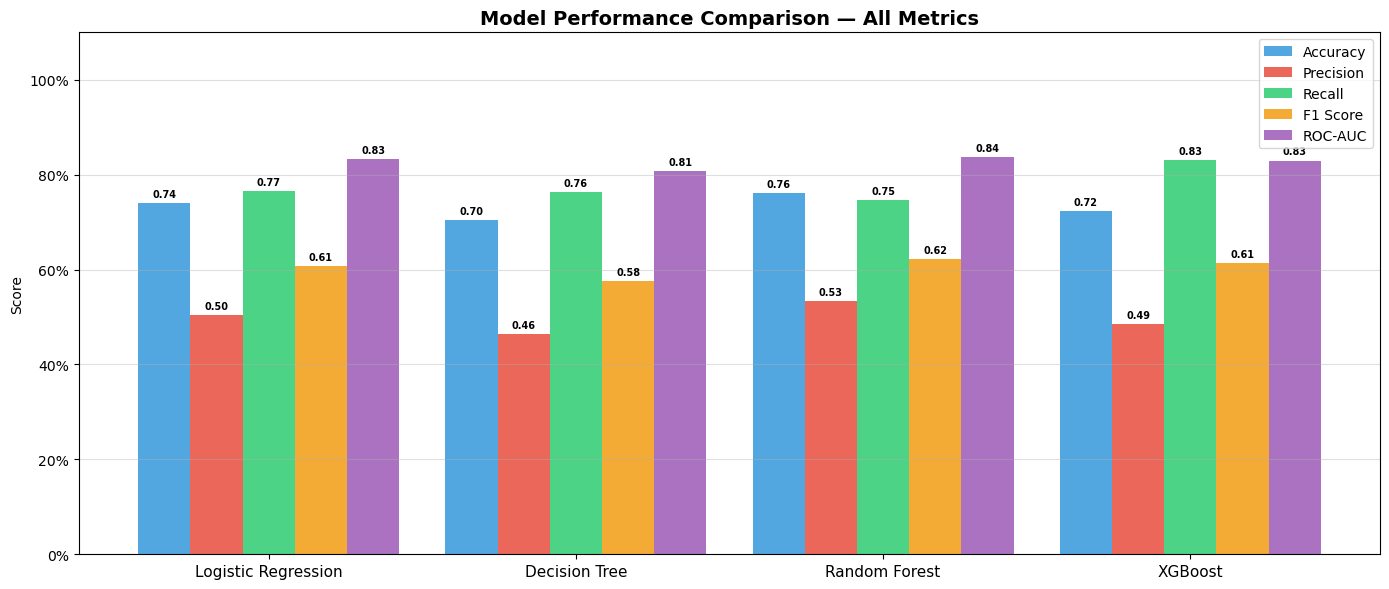

In [24]:
# Bar chart comparison
plot_df = comparison_df.drop('Rule-Based (Baseline)').astype(float)

fig, ax = plt.subplots(figsize=(14, 6))

x = np.arange(len(plot_df.index))
width = 0.17
cols = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC-AUC']
palette = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12', '#9b59b6']

for i, (col, color) in enumerate(zip(cols, palette)):
    bars = ax.bar(x + i * width, plot_df[col], width, label=col, color=color, alpha=0.85)
    for bar in bars:
        ax.annotate(f'{bar.get_height():.2f}',
                    xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
                    xytext=(0, 3), textcoords="offset points",
                    ha='center', va='bottom', fontsize=7, fontweight='bold')

ax.set_xticks(x + width * 2)
ax.set_xticklabels(plot_df.index, fontsize=11)
ax.set_ylim(0, 1.1)
ax.set_ylabel('Score')
ax.set_title('Model Performance Comparison — All Metrics', fontsize=14, fontweight='bold')
ax.legend(loc='upper right')
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0))
ax.grid(axis='y', alpha=0.4)

plt.tight_layout()
plt.savefig('../results/model_comparison_bar.png', bbox_inches='tight')
plt.show()


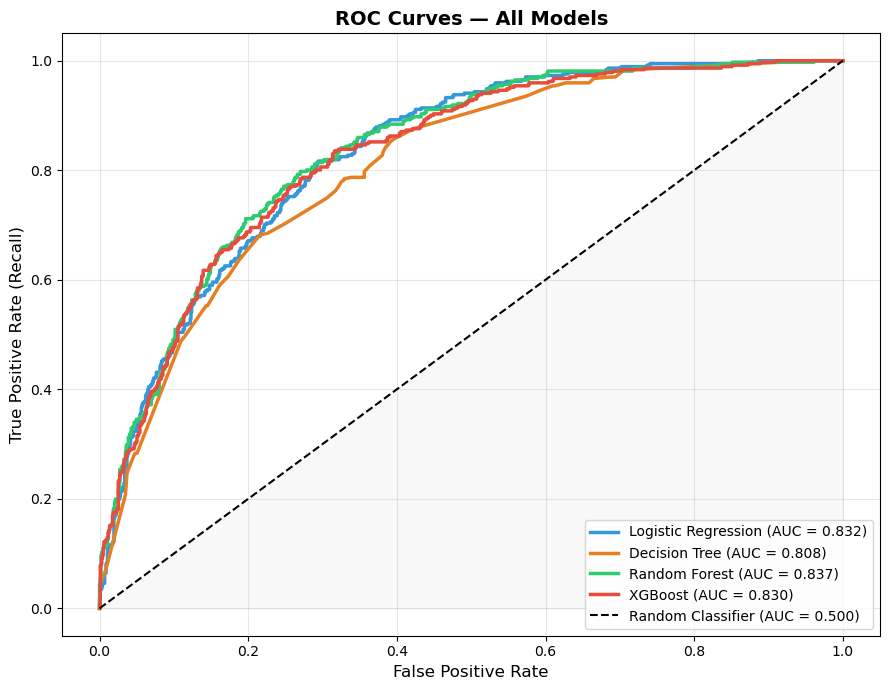

In [25]:
# ROC Curves for all 4 models
fig, ax = plt.subplots(figsize=(9, 7))

colors = ['#3498db', '#e67e22', '#2ecc71', '#e74c3c']
for r, color in zip(results, colors):
    fpr, tpr, _ = roc_curve(y_test, r['y_prob'])
    ax.plot(fpr, tpr, label=f"{r['Model']} (AUC = {r['ROC-AUC']:.3f})",
            linewidth=2.5, color=color)

ax.plot([0, 1], [0, 1], 'k--', linewidth=1.5, label='Random Classifier (AUC = 0.500)')
ax.fill_between([0, 1], [0, 1], alpha=0.05, color='grey')

ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate (Recall)', fontsize=12)
ax.set_title('ROC Curves — All Models', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../results/roc_curves.png', bbox_inches='tight')
plt.show()


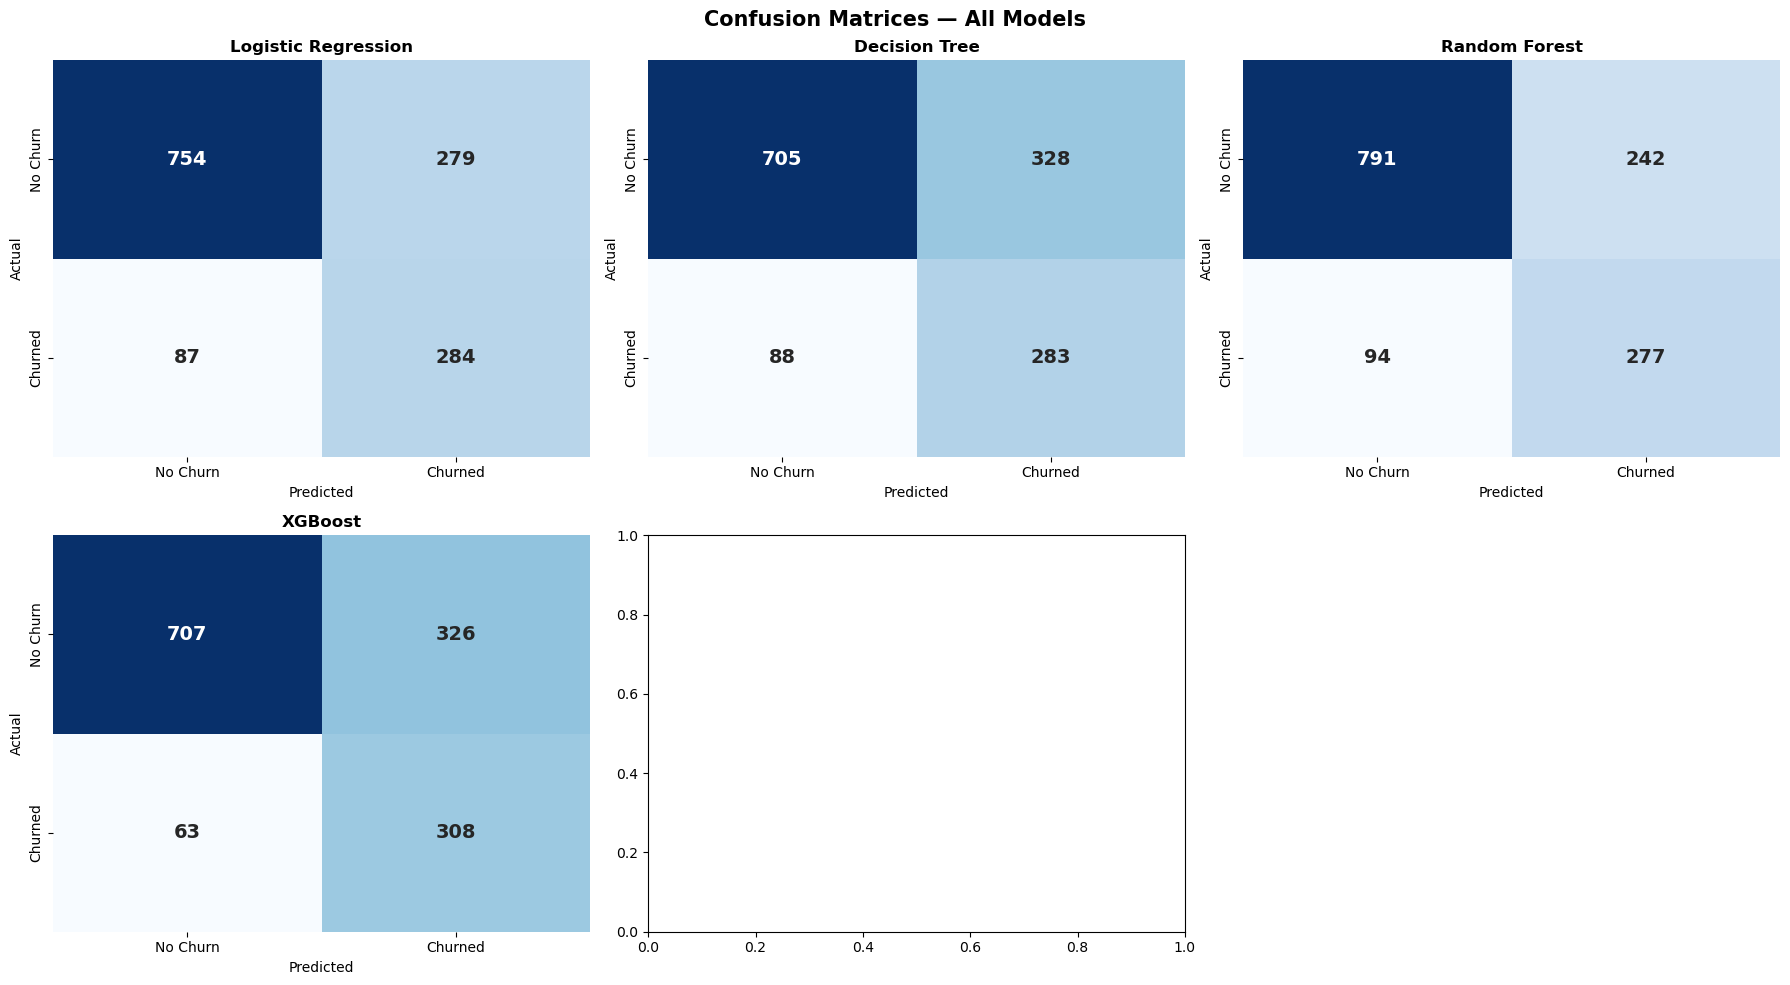

In [26]:
# Confusion Matrices
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Confusion Matrices — All Models', fontsize=15, fontweight='bold')

axes_flat = axes.flatten()
for i, r in enumerate(results):
    cm = confusion_matrix(y_test, r['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', ax=axes_flat[i],
                cmap='Blues', cbar=False,
                xticklabels=['No Churn', 'Churned'],
                yticklabels=['No Churn', 'Churned'],
                annot_kws={'size': 14, 'weight': 'bold'})
    axes_flat[i].set_title(r['Model'], fontsize=12, fontweight='bold')
    axes_flat[i].set_ylabel('Actual')
    axes_flat[i].set_xlabel('Predicted')

axes_flat[5].set_visible(False)

plt.tight_layout()
plt.savefig('../results/confusion_matrices.png', bbox_inches='tight')
plt.show()

In [27]:
# Cross-Validation 
print("Cross-Validation Results (5-Fold Stratified):")
print("=" * 55)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_models = {
    'Logistic Regression': lr_model,
    'Decision Tree'      : dt_model,
    'Random Forest'      : rf_model,
    'XGBoost'            : xgb_model
}

for name, model in cv_models.items():
    scores = cross_val_score(model, X_train_bal, y_train_bal, cv=cv, scoring='f1', n_jobs=-1)
    print(f"  {name:<25} F1: {scores.mean():.4f} ± {scores.std():.4f}")


Cross-Validation Results (5-Fold Stratified):
  Logistic Regression       F1: 0.7817 ± 0.0125
  Decision Tree             F1: 0.7803 ± 0.0154
  Random Forest             F1: 0.8104 ± 0.0113
  XGBoost                   F1: 0.8315 ± 0.0064


In [28]:
import os
import joblib

os.makedirs('../models', exist_ok=True)

joblib.dump(lr_model,  '../models/logistic_regression.pkl')
joblib.dump(dt_model,  '../models/decision_tree.pkl')
joblib.dump(rf_model,  '../models/random_forest.pkl')
joblib.dump(xgb_model, '../models/xgboost.pkl')
joblib.dump(scaler,    '../models/scaler.pkl')

print("All models saved to /models/ ")
print("To load: model = joblib.load('../models/random_forest.pkl')")


All models saved to /models/ 
To load: model = joblib.load('../models/random_forest.pkl')
